In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
reservas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/colab_data/hotel_bookings.csv', sep=',', decimal='.')

In [2]:
reservas.describe( )

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [3]:
# #Filtragem de variaveis métricas, apenas rsv sem ADR com valores enganosos#
reservas_limpo = reservas[(reservas['adr'] > 0) & (reservas['adr'] < 1000)]
acs=reservas_limpo[['arrival_date_year', 'arrival_date_day_of_month', 'adr', 'stays_in_weekend_nights','adults','children','babies']]
acs.describe ()


,arrival_date_year,arrival_date_day_of_month,adr,stays_in_weekend_nights,adults,children,babies
count,117429.000000,117429.000000,117429.000000,117429.000000,117429.000000,117425.000000,117429.000000
mean,2016.160276,15.802740,103.485715,0.936430,1.860631,0.104509,0.007869
std,0.706567,8.783578,46.708039,0.995761,0.482104,0.399698,0.097169
min,2015.000000,1.000000,0.260000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,8.000000,70.530000,0.000000,2.000000,0.000000,0.000000
50%,2016.000000,16.000000,95.000000,1.000000,2.000000,0.000000,0.000000
75%,2017.000000,23.000000,126.000000,2.000000,2.000000,0.000000,0.000000
max,2017.000000,31.000000,510.000000,19.000000,4.000000,10.000000,10.000000


In [4]:
#Filtragem de variaveis categoricas
acs_cat=reservas_limpo[['arrival_date_month', 'country', 'hotel','market_segment']]

O perfil dos hóspedes que se hospedam é de «casais» **(média de 1,86)**, e as reservas com crianças e bebês são praticamente inexistentes **(média de 0,10)**.
Quanto aos hábitos de ocupação, os hóspedes costumam reservar pelo menos uma noite **(média de 0,93)** durante os fins de semana. A tarifa média costuma ficar em torno de **US$ 103,48**, com uma exceção que chega a **US$ 510** por noite.

In [5]:
#Quien cuando y que categoria representa valor MAX
#Métricas Base
reservas_limpo[reservas_limpo['adr']==510]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
111403,City Hotel,0,0,2017,May,19,9,0,1,1,...,No Deposit,159.0,NaN,0,Transient,510.0,0,0,Check-Out,2017-05-10


Podemos observar, que fue contratada CAT 'A' por un PAX internacinoal ITA, quien se ha hospedo por una noche 09/05/2017

Vimos, tratamos y limpiamos los datos a ser analisados segun el interes.Separamos nuestro analisis por Variables metricas quantitativas y variables categoricas com frequencias.

In [6]:
#selecionamos la variables de interes Metrico
acs = reservas_limpo[['adr', 'arrival_date_year', 'adults','children', 'babies']]
acs.describe()


,adr,arrival_date_year,adults,children,babies
count,117429.000000,117429.000000,117429.000000,117425.000000,117429.000000
mean,103.485715,2016.160276,1.860631,0.104509,0.007869
std,46.708039,0.706567,0.482104,0.399698,0.097169
min,0.260000,2015.000000,0.000000,0.000000,0.000000
25%,70.530000,2016.000000,2.000000,0.000000,0.000000
50%,95.000000,2016.000000,2.000000,0.000000,0.000000
75%,126.000000,2017.000000,2.000000,0.000000,0.000000
max,510.000000,2017.000000,4.000000,10.000000,10.000000


In [7]:
print(reservas_limpo.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [8]:
#Somamos total de PAX. Cual es nuestro TARGET?
acs['children']= acs['children'].fillna(0)
total_pax = acs[['adults', 'children', 'babies']].copy ()
total_pax['suma']= total_pax['adults'] + total_pax['children'] + total_pax['babies']
total_pax.describe()

/tmp/ipykernel_215/1800617513.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acs['children']= acs['children'].fillna(0)


,adults,children,babies,suma
count,117429.000000,117429.000000,117429.000000,117429.000000
mean,1.860631,0.104506,0.007869,1.973005
std,0.482104,0.399691,0.097169,0.647250
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,2.000000
50%,2.000000,0.000000,0.000000,2.000000
75%,2.000000,0.000000,0.000000,2.000000
max,4.000000,10.000000,10.000000,12.000000


podemos ver, segun el 25%, mediana 50% y 75% que mayormente se hospedan ADL o sea parejas sin CHD. En la columna suma, vemos que en media se hospedan 2 personas por habitacion. Inconsistencia, columna SUMA min 0. RESERVAS SIN HUESPEDES?

Inconsistencias, devido a motivos desconocidos, posibles Gratuidades (USO-DA-CASA) Manuntencion o rsv canceladas. #Limpieza de datos con reservas reales

In [9]:
#Reserva con valores arriba de 0
reservas_reales=total_pax[total_pax['suma'] > 0]
reservas_reales.describe()

,adults,children,babies,suma
count,117398.000000,117398.000000,117398.000000,117398.000000
mean,1.861122,0.104533,0.007871,1.973526
std,0.481218,0.399741,0.097182,0.646541
min,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,2.000000
50%,2.000000,0.000000,0.000000,2.000000
75%,2.000000,0.000000,0.000000,2.000000
max,4.000000,10.000000,10.000000,12.000000


Podemos concluir de esta forma, que en min hay 1 PAX hospedado despues de la limpieza. Ahora, ya analizamos el MIN vamos por el MAX.

In [10]:
#Que reservas representan el MAX de SUMA de PAX?
total_pax[total_pax['suma']==12]
reservas_limpo.loc[[328, 46619]]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
328,Resort Hotel,1,55,2015,July,29,12,4,10,2,...,No Deposit,8.0,NaN,0,Contract,133.16,0,1,No-Show,2015-07-12
46619,City Hotel,0,37,2016,January,3,12,0,2,2,...,No Deposit,9.0,NaN,0,Transient,84.45,0,1,Check-Out,2016-01-14


Cuanto pagaron rsv que se hospedaron con 10 criaturas CHD 1 Y CHD2?

In [11]:
reservas_limpo.loc[[328, 46619]], ['adr', 'total_of_special_requests']

(              hotel  is_canceled  lead_time  arrival_date_year  \
 328    Resort Hotel            1         55               2015   
 46619    City Hotel            0         37               2016   
 
       arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
 328                 July                        29                         12   
 46619            January                         3                         12   
 
        stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
 328                          4                    10       2  ...   
 46619                        0                     2       2  ...   
 
        deposit_type  agent company days_in_waiting_list customer_type     adr  \
 328      No Deposit    8.0     NaN                    0      Contract  133.16   
 46619    No Deposit    9.0     NaN                    0     Transient   84.45   
 
        required_car_parking_spaces  total_of_special_requests  \
 328                   

Reserva 328 si bien, hubo pagamento no hubieron consumos mayores a diferencia de la reserva de #46619. Prosiguiendo con el objetivo de apresentar un analisis de consumo sazonal, distinguendo las reservas que si hicieron check out y los meses de mayor/menor movimiento en el hotel

In [12]:
#Analisis Estacional Tiempo vs Diner: Total de noches reservadas
reservas_limpo['total_nights'] = reservas_limpo['stays_in_week_nights'] + reservas_limpo['stays_in_weekend_nights']
reservas_limpo.head()

/tmp/ipykernel_215/481271768.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservas_limpo['total_nights'] = reservas_limpo['stays_in_week_nights'] + reservas_limpo['stays_in_weekend_nights']


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03,2


In [13]:
reservas_limpo['reservation_status'].unique()

array(['Check-Out', 'Canceled', 'No-Show'], dtype=object)

In [14]:
#Manipulacion de Datos: Datos promedios entre ADR Y Cantidad de Noches
df_consumo=reservas_limpo[ (reservas_limpo['total_nights']>0) & (reservas_limpo['reservation_status']=='Check-Out')]
df_consumo.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_nights
count,73419.0,73419.000000,73419.000000,73419.000000,73419.000000,73419.000000,73419.000000,73419.000000,73419.000000,73419.000000,...,73419.000000,73419.000000,73419.000000,61934.00000,5239.000000,73419.000000,73419.000000,73419.000000,73419.000000,73419.000000
mean,0.0,81.035781,2016.152563,27.036380,15.845708,0.941895,2.493987,1.839374,0.103134,0.010311,...,0.014233,0.186764,0.287487,93.86258,196.288223,1.597161,102.366980,0.100192,0.716490,3.435882
std,0.0,91.180763,0.701859,13.866466,8.779634,0.988300,1.902268,0.502612,0.392163,0.112983,...,0.264237,1.752778,0.711294,113.86722,131.541052,14.854480,47.278936,0.304447,0.832917,2.542389
min,0.0,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.00000,6.000000,0.000000,0.260000,0.000000,0.000000,1.000000
25%,0.0,9.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.00000,67.000000,0.000000,70.000000,0.000000,0.000000,2.000000
50%,0.0,47.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,14.00000,204.000000,0.000000,94.500000,0.000000,1.000000,3.000000
75%,0.0,126.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,240.00000,274.000000,0.000000,126.000000,0.000000,1.000000,4.000000
max,0.0,709.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,4.000000,3.000000,10.000000,...,13.000000,72.000000,18.000000,535.00000,541.000000,379.000000,510.000000,8.000000,5.000000,69.000000


In [15]:
#Calculo a nivel de fila y Metrica de negocio (df_revenue)
df_consumo['df_revenue'] = df_consumo['adr']* df_consumo['total_nights']
df_consumo.head(50)

/tmp/ipykernel_215/1015310947.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_consumo['df_revenue'] = df_consumo['adr']* df_consumo['total_nights']


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,df_revenue
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,1,75.00
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,1,75.00
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,2,196.00
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,2,196.00
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03,2,214.00
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,NaN,0,Transient,103.00,0,1,Check-Out,2015-07-03,2,206.00
11,Resort Hotel,0,35,2015,July,27,1,0,4,2,...,NaN,0,Transient,145.00,0,0,Check-Out,2015-07-05,4,580.00
12,Resort Hotel,0,68,2015,July,27,1,0,4,2,...,NaN,0,Transient,97.00,0,3,Check-Out,2015-07-05,4,388.00
13,Resort Hotel,0,18,2015,July,27,1,0,4,2,...,NaN,0,Transient,154.77,0,1,Check-Out,2015-07-05,4,619.08
14,Resort Hotel,0,37,2015,July,27,1,0,4,2,...,NaN,0,Transient,94.71,0,0,Check-Out,2015-07-05,4,378.84


Promedio de Tarifário dependiendo del Mes

In [16]:
reservas_limpo[['arrival_date_month', 'adr']].groupby(by=['arrival_date_month']).mean()

,adr
arrival_date_month,
April,101.627187
August,141.807862
December,83.783042
February,74.947835
January,71.913773
July,128.513572
June,117.966273
March,81.409007
May,110.380573


Cuanto gasta una persona promedio dependiendo de los dias que se esté hospedando? Aqui podemos concluir dos cosas: Si bien, Agosto es uno de los meses con el mayor demanda por ende un valor mas alto que el de los demas meses en el Average Daily Rate podemos decir que en relacion a la cantidad de noches reservas Julio es de los meses con mayor hospedaje, creeriamos, vacaciones estudiantiles, etc. Apesar de que enero, sea el mes con el precio mas accesible, el nivel de demanda ocupacional no remite a una direncia abismal entre los meses de mayor resgate monetario. Se podrian crear, mayores atractivos para los meses con menor ADR para generar, mayores ingresos.

Consolidar la hisotoria entre July vs January

In [17]:
#Elasticidad de demanda
reservas_limpo[['adr', 'total_nights', 'arrival_date_month']].groupby(by=['arrival_date_month']).mean()


,adr,total_nights
arrival_date_month,,
April,101.627187,3.388935
August,141.807862,3.919772
December,83.783042,3.288066
February,74.947835,3.062871
January,71.913773,3.004999
July,128.513572,3.947162
June,117.966273,3.602643
March,81.409007,3.441494
May,110.380573,3.309879


Cuanto pagó por noche y Cuantas noches se quedó? Antes, como el orden de las categorias del calendario arrival_date_month no estarian ordenadas para entender mejor los graficos y resultados, debemos crear un orden categorico para recrear un nuevo calendario y de esa forma, hacerle entender a python que es ese el orden que debe respetar y no el anterior

In [18]:
#Como estan ordenados los meses?
reservas_limpo['arrival_date_month'].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [19]:
#Crear lista de Categoria
month_of_year = ['January', 'February','March','April','May','June','July','August','September','October','November','December']
print (month_of_year)


['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


In [20]:
#Data Wrangling Gasto promedio mensual
reservas_limpo['arrival_date_month']=pd.Categorical(reservas_limpo['arrival_date_month'], categories =month_of_year , ordered=True)
reservas_limpo.info()

/tmp/ipykernel_215/370642826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservas_limpo['arrival_date_month']=pd.Categorical(reservas_limpo['arrival_date_month'], categories =month_of_year , ordered=True)


<class 'pandas.core.frame.DataFrame'>
Index: 117429 entries, 2 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           117429 non-null  object  
 1   is_canceled                     117429 non-null  int64   
 2   lead_time                       117429 non-null  int64   
 3   arrival_date_year               117429 non-null  int64   
 4   arrival_date_month              117429 non-null  category
 5   arrival_date_week_number        117429 non-null  int64   
 6   arrival_date_day_of_month       117429 non-null  int64   
 7   stays_in_weekend_nights         117429 non-null  int64   
 8   stays_in_week_nights            117429 non-null  int64   
 9   adults                          117429 non-null  int64   
 10  children                        117425 non-null  float64 
 11  babies                          117429 non-null  int64   
 12  meal   

In [21]:
#Arquitectura del analisis. Segmentacion, Fragmentacion y Estacionalidad
df_consumo[['arrival_date_month', 'hotel','df_revenue']].groupby(by=['hotel','arrival_date_month']).sum()

df_revenue
hotel        arrival_date_month            
City Hotel   April               1369897.57
             August              1978102.45
             December             641440.73
             February             768886.74
             January              527932.98
             July                1686277.58
             June                1467868.67
             March               1096602.16
             May                 1569623.77
             November             687443.09
             October             1241013.13
             September           1359321.31
Resort Hotel April                729959.91
             August              2939056.61
             December             445951.56
             February             378654.74
             January              248743.86
             July                2414119.49
             June                1115422.25
             March                555560.23
             May                  825589.87
             November             348109.87
             October              615803.59
             September            984942.05

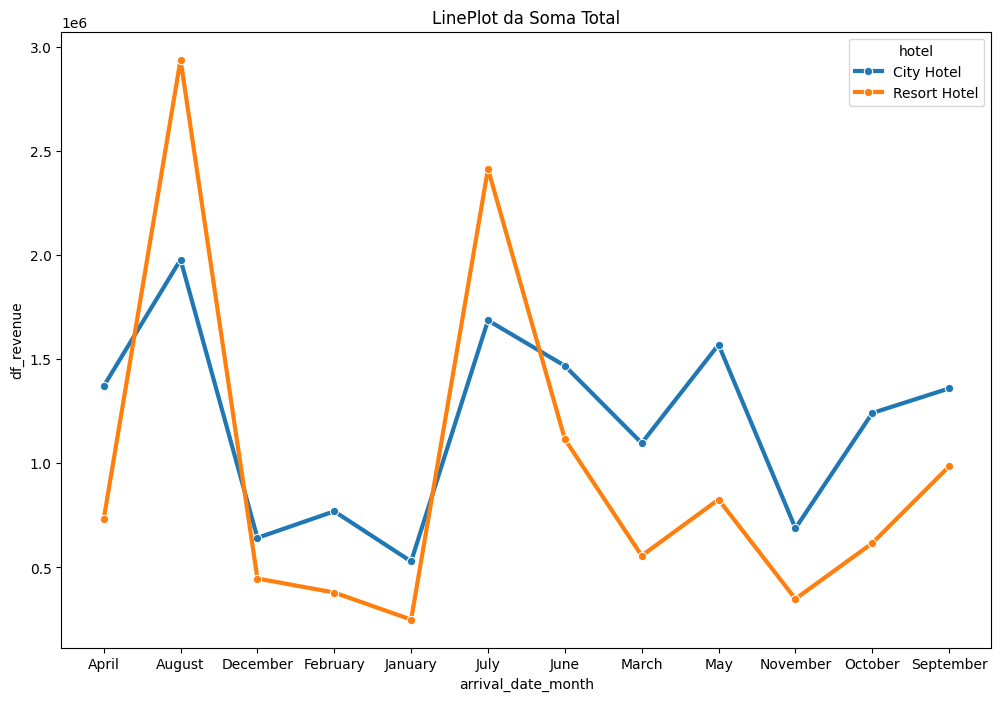

In [22]:
#1  Gráfico que representa el valor total segun Hotel vs Tiempo (meses) ¿Que paso?
variable=df_consumo[['arrival_date_month', 'hotel','df_revenue']].groupby(by=['hotel','arrival_date_month']).sum() .reset_index()
#2
plt.figure(figsize=(12,8), dpi=(100))
sns.lineplot(data=variable, x='arrival_date_month', y='df_revenue', hue='hotel', marker='o',linewidth=3, color='orange')
plt.title('LinePlot da Soma Total', fontsize=12)
plt.show()